## imports and device setup

In [1]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Set the device to GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


Total number of classes: 27

Top 5 most represented styles:
 - Impressionism: 13060 images
 - Realism: 10733 images
 - Romanticism: 7019 images
 - Expressionism: 6736 images
 - Post_Impressionism: 6450 images

5 least represented styles:
 - Contemporary_Realism: 481 images
 - New_Realism: 314 images
 - Synthetic_Cubism: 216 images
 - Analytical_Cubism: 110 images
 - Action_painting: 98 images


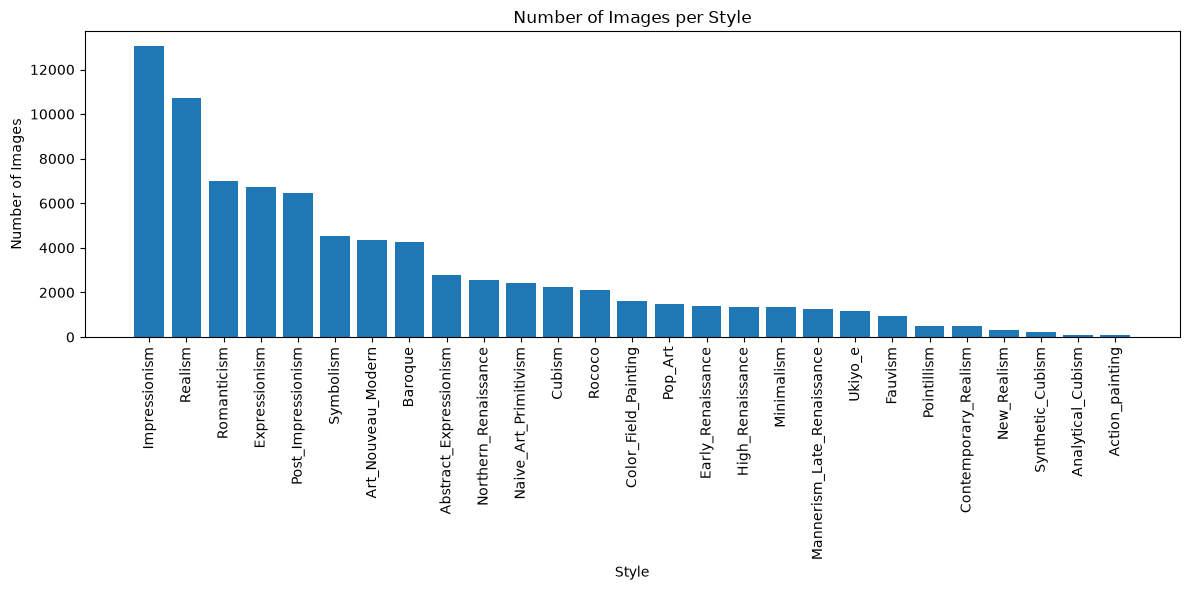

In [2]:
# File paths and class counts
data_dir = "WikiArt/wikiart/versions/1/"
classes = sorted(os.listdir(data_dir))
print(f"Total number of classes: {len(classes)}\n")

class_counts = {}
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

# Sort and display the class counts
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
print("Top 5 most represented styles:")
for name, count in sorted_counts[:5]:
    print(f" - {name}: {count} images")

print("\n5 least represented styles:")
for name, count in sorted_counts[-5:]:
    print(f" - {name}: {count} images")



# display plot with all styles and their counts ascending order
plt.figure(figsize=(12, 6))
plt.bar([x[0] for x in sorted_counts], [x[1] for x in sorted_counts])
plt.xticks(rotation=90)
plt.title("Number of Images per Style")
plt.xlabel("Style")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

## Own Dataset class

In [3]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class WikiArtDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.image_paths = []
        self.labels = []
        
        # Populate image paths and labels
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                for img_name in os.listdir(cls_dir):
                    self.image_paths.append(os.path.join(cls_dir, img_name))
                    self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Transform pipeline for the dataset
transform = transforms.Compose([
    transforms.Resize((128, 128)), # Minimalised size for faster processing
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


custom_dataset = WikiArtDataset(root_dir=data_dir, transform=transform)

print(f"Dataset načten: {len(custom_dataset)} images, {len(custom_dataset.classes)} classes.")

Dataset načten: 81444 images, 27 classes.


## Baseline architecture from scratch

In [4]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=27):
        super(SimpleCNN, self).__init__()
        # Out images: 3 channels (RGB), 128x128
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # After 3 pooling layers, the image size will be reduced from 128x128 to 16x16
        self.fc1 = nn.Linear(64 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1) # Flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN(num_classes=len(custom_dataset.classes)).to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=16384, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=27, bias=True)
)


## Overfit Sanity Check

In [5]:
import torch.optim as optim
import torch

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 16 samples sanity check
sanity_loader = DataLoader(custom_dataset, batch_size=16, shuffle=True)
inputs, labels = next(iter(sanity_loader))
inputs, labels = inputs.to(device), labels.to(device)

print("Start overfitting sanity check (16 samples)...")
model.train()

for epoch in range(25): 
    optimizer.zero_grad()       # 1. Zero gradients
    outputs = model(inputs)     # 2. Forward pass
    loss = criterion(outputs, labels) # 3. loss computation
    loss.backward()             # 4. Backward pass
    optimizer.step()            # 5. Update weights

    # Accuracy calculation
    _, preds = torch.max(outputs, 1)
    acc = torch.sum(preds == labels).item() / len(labels)

    
    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f} | Accuracy: {acc*100:.1f}%")

Start overfitting sanity check (16 samples)...
Epoch 1 | Loss: 3.2900 | Accuracy: 0.0%
Epoch 2 | Loss: 2.3334 | Accuracy: 12.5%
Epoch 3 | Loss: 1.8554 | Accuracy: 43.8%
Epoch 4 | Loss: 1.0747 | Accuracy: 81.2%
Epoch 5 | Loss: 0.7002 | Accuracy: 87.5%
Epoch 6 | Loss: 0.2125 | Accuracy: 100.0%
Epoch 7 | Loss: 0.0765 | Accuracy: 100.0%
Epoch 8 | Loss: 0.0355 | Accuracy: 100.0%
Epoch 9 | Loss: 0.0095 | Accuracy: 100.0%
Epoch 10 | Loss: 0.0017 | Accuracy: 100.0%
Epoch 11 | Loss: 0.0003 | Accuracy: 100.0%
Epoch 12 | Loss: 0.0000 | Accuracy: 100.0%
Epoch 13 | Loss: 0.0000 | Accuracy: 100.0%
Epoch 14 | Loss: 0.0000 | Accuracy: 100.0%
Epoch 15 | Loss: 0.0000 | Accuracy: 100.0%
Epoch 16 | Loss: 0.0000 | Accuracy: 100.0%
Epoch 17 | Loss: 0.0000 | Accuracy: 100.0%
Epoch 18 | Loss: 0.0000 | Accuracy: 100.0%
Epoch 19 | Loss: 0.0000 | Accuracy: 100.0%
Epoch 20 | Loss: 0.0000 | Accuracy: 100.0%
Epoch 21 | Loss: 0.0000 | Accuracy: 100.0%
Epoch 22 | Loss: 0.0000 | Accuracy: 100.0%
Epoch 23 | Loss: 0.000

## Full training cycle

In [7]:
from torch.utils.data import random_split, DataLoader

# Rozdělení custom_dataset na 80 % trénovacích a 20 % validačních dat
train_size = int(0.8 * len(custom_dataset))
val_size = len(custom_dataset) - train_size

# Pevný seed pro reprodukovatelnost (užitečné při obhajobě)
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(custom_dataset, [train_size, val_size], generator=generator)

# Vytvoření chybějících DataLoaderů
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print(f"Trénovací sada: {len(train_dataset)}")
print(f"Validační sada: {len(val_dataset)}")

Trénovací sada: 65155
Validační sada: 16289


In [9]:
import time
from tqdm import tqdm

num_epochs = 5
print("Full training started...")

for epoch in range(num_epochs):
    start_time = time.time()
    
    # --- TRÉNOVACÍ FÁZE ---
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # Zabalení dataloaderu do tqdm pro zobrazení progress baru
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    
    for inputs, labels in train_loop:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels).item()
        total_train += labels.size(0)
        
        # Průběžná aktualizace loss hodnoty v progress baru
        train_loop.set_postfix(loss=running_train_loss/total_train)
        
    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train
    
    # --- VALIDAČNÍ FÁZE ---
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  ")
    
    with torch.no_grad():
        for inputs, labels in val_loop:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels).item()
            total_val += labels.size(0)
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    
    time_elapsed = time.time() - start_time
    print(f"Shrnutí epochy {epoch+1} [{time_elapsed:.0f}s]: Train Acc: {epoch_train_acc*100:.2f}% | Val Acc: {epoch_val_acc*100:.2f}%\n")

Full training started...


Epoch 1/5 [Train]:   0%|          | 0/2037 [00:00<?, ?it/s]

Epoch 1/5 [Val]  : 100%|██████████| 510/510 [01:27<00:00,  5.86it/s]


Shrnutí epochy 1 [440s]: Train Acc: 28.32% | Val Acc: 32.02%



Epoch 2/5 [Val]  : 100%|██████████| 510/510 [01:30<00:00,  5.65it/s]


...

Shrnutí epochy 3 [465s]: Train Acc: 42.72% | Val Acc: 33.36%



Epoch 4/5 [Val]  : 100%|██████████| 510/510 [01:24<00:00,  6.05it/s]


Shrnutí epochy 4 [427s]: Train Acc: 54.72% | Val Acc: 34.69%



Epoch 5/5 [Val]  : 100%|██████████| 510/510 [01:24<00:00,  6.03it/s]

Shrnutí epochy 5 [446s]: Train Acc: 69.31% | Val Acc: 31.73%



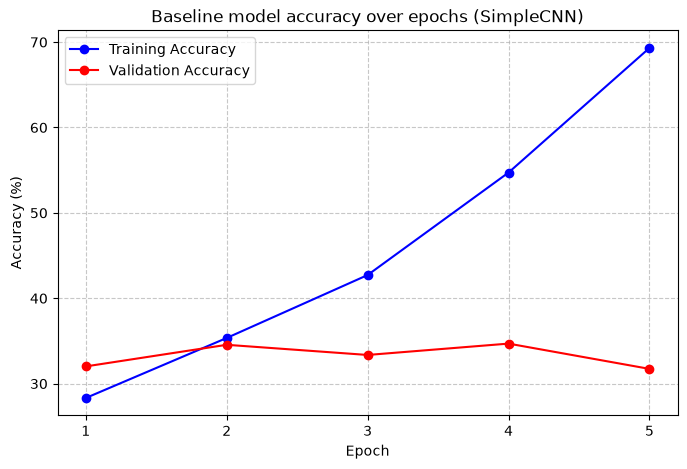

In [11]:
import matplotlib.pyplot as plt

# Values from the current run
epochs = range(1, 6)
train_acc = [28.32, 35.35, 42.72, 54.72, 69.31]
val_acc = [32.02, 34.55, 33.36, 34.69, 31.73]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Baseline model accuracy over epochs (SimpleCNN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()